# Word Clouds for False Positive and False Negative Reviews

This notebook reads the saved `lora_test_predictions.csv` file and creates two word clouds:

- **False Positive (FP):** actual label is `negative (0)`, but the model predicts `positive (1)`.
- **False Negative (FN):** actual label is `positive (1)`, but the model predicts `negative (0)`.

The original prediction file stores review text in the `review_preview` column.  
The generated images are saved in a `wordclouds` folder next to the CSV file.

In [1]:
# Install and import dependencies
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("wordcloud") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "wordcloud"]
    )

import html
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS

print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 1. Locate and load the prediction file

The default project directory follows the original training notebook:

- Google Colab: `/content/drive/MyDrive/qwen3_imdb_lora`
- Local environment: `./qwen3_imdb_lora`

If the CSV file is not found there, the code searches the current directory and `/content`.

In [2]:
# Mount Google Drive automatically when running in Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print("Google Drive could not be mounted:", exc)

PROJECT_DIR = (
    Path("/content/drive/MyDrive/qwen3_imdb_lora")
    if IN_COLAB
    else Path("./qwen3_imdb_lora")
)

CSV_PATH = PROJECT_DIR / "results" / "lora_test_predictions.csv"

if not CSV_PATH.exists():
    search_roots = [Path.cwd()]

    if Path("/content").exists():
        search_roots.append(Path("/content"))

    matches = []

    for root in search_roots:
        try:
            matches.extend(root.rglob("lora_test_predictions.csv"))
        except (PermissionError, OSError):
            pass

    unique_matches = list(dict.fromkeys(matches))
    unique_matches.sort(
        key=lambda path: (
            "qwen3_imdb_lora" not in str(path),
            "results" not in str(path),
            len(str(path)),
        )
    )

    if unique_matches:
        CSV_PATH = unique_matches[0]
    else:
        raise FileNotFoundError(
            "Could not find lora_test_predictions.csv. "
            "Run the prediction-export cell in the original notebook first, "
            "or manually update CSV_PATH."
        )

print("Prediction file:", CSV_PATH)

predictions = pd.read_csv(CSV_PATH)

print("Dataset shape:", predictions.shape)
print("Columns:", predictions.columns.tolist())

display(predictions.head())

Prediction file: qwen3_imdb_lora\results\lora_test_predictions.csv
Dataset shape: (25000, 10)
Columns: ['index', 'true_label', 'true_label_text', 'prediction', 'prediction_text', 'correct', 'raw_output', 'prompt_tokens', 'seconds', 'review_preview']


,index,true_label,true_label_text,prediction,prediction_text,correct,raw_output,prompt_tokens,seconds,review_preview
0,0,1,positive,1,positive,True,positive,401,0.051601,"When I unsuspectedly rented A Thousand Acres, ..."
1,1,1,positive,0,negative,False,negative,270,0.051601,This is the latest entry in the long series of...
2,2,0,negative,0,negative,True,negative,192,0.051601,This movie was so frustrating. Everything seem...
3,3,1,positive,1,positive,True,positive,180,0.051601,"I was truly and wonderfully surprised at ""O' B..."
4,4,0,negative,0,negative,True,negative,146,0.051601,This movie spends most of its time preaching t...


## 2. Normalize labels and select the two error groups

In [3]:
def normalize_binary_label(series: pd.Series) -> pd.Series:
    """Convert common binary-label formats to 0 and 1."""

    text = series.astype(str).str.strip().str.lower()

    mapping = {
        "negative": 0,
        "positive": 1,
        "false": 0,
        "true": 1,
        "0": 0,
        "1": 1,
        "0.0": 0,
        "1.0": 1,
    }

    mapped = text.map(mapping)
    numeric = pd.to_numeric(series, errors="coerce")

    return mapped.fillna(numeric).astype("Int64")


required_columns = {"true_label", "prediction"}
missing_columns = required_columns - set(predictions.columns)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

predictions = predictions.copy()

predictions["true_label_id"] = normalize_binary_label(
    predictions["true_label"]
)
predictions["prediction_id"] = normalize_binary_label(
    predictions["prediction"]
)

# False Positive:
# actual negative (0), predicted positive (1)
false_positive = predictions.loc[
    (predictions["true_label_id"] == 0)
    & (predictions["prediction_id"] == 1)
].copy()

# False Negative:
# actual positive (1), predicted negative (0)
false_negative = predictions.loc[
    (predictions["true_label_id"] == 1)
    & (predictions["prediction_id"] == 0)
].copy()

summary = pd.DataFrame(
    {
        "Group": [
            "False Positive: negative → positive",
            "False Negative: positive → negative",
        ],
        "Number of reviews": [
            len(false_positive),
            len(false_negative),
        ],
    }
)

display(summary)

if false_positive.empty:
    print("Warning: the False Positive group is empty.")

if false_negative.empty:
    print("Warning: the False Negative group is empty.")

,Group,Number of reviews
0,False Positive: negative → positive,524
1,False Negative: positive → negative,690


## 3. Prepare the review text

The notebook first looks for `review_preview`, which is the column used by the original notebook.  
It can also handle several common alternative text-column names.

In [4]:
TEXT_COLUMN_CANDIDATES = [
    "review_preview",
    "review",
    "review_text",
    "text",
    "content",
]

TEXT_COLUMN = next(
    (
        column
        for column in TEXT_COLUMN_CANDIDATES
        if column in predictions.columns
    ),
    None,
)

if TEXT_COLUMN is None:
    raise KeyError(
        "No review-text column was found. Available columns: "
        + ", ".join(predictions.columns.astype(str))
    )

print("Review text column:", TEXT_COLUMN)


def clean_review_text(value) -> str:
    """Clean HTML and retain English words for the word cloud."""

    text = html.unescape(str(value))
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^A-Za-z']+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()

    return text


CUSTOM_STOPWORDS = set(STOPWORDS)

CUSTOM_STOPWORDS.update(
    {
        "movie",
        "film",
        "one",
        "really",
        "would",
        "could",
        "also",
        "even",
        "much",
        "get",
        "got",
        "make",
        "made",
        "see",
        "seen",
        "watch",
        "watched",
        "character",
        "characters",
    }
)


def combine_reviews(frame: pd.DataFrame) -> str:
    cleaned_reviews = (
        frame[TEXT_COLUMN]
        .dropna()
        .map(clean_review_text)
    )

    cleaned_reviews = cleaned_reviews[
        cleaned_reviews.str.len() > 0
    ]

    return " ".join(cleaned_reviews.tolist())


false_positive_text = combine_reviews(false_positive)
false_negative_text = combine_reviews(false_negative)

print(
    "False Positive text length:",
    len(false_positive_text),
)

print(
    "False Negative text length:",
    len(false_negative_text),
)

Review text column: review_preview
False Positive text length: 406369
False Negative text length: 563264


## 4. Define the word-cloud function

In [5]:
OUTPUT_DIR = CSV_PATH.parent / "wordclouds"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def create_wordcloud(
    text: str,
    title: str,
    output_path: Path,
) -> WordCloud:
    """Generate, display, and save one word cloud."""

    if not text.strip():
        raise ValueError(
            f"No usable review text is available for: {title}"
        )

    cloud = WordCloud(
        width=1600,
        height=900,
        stopwords=CUSTOM_STOPWORDS,
        collocations=False,
        random_state=42,
    ).generate(text)

    plt.figure(figsize=(16, 9))
    plt.imshow(cloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)

    return cloud

## 5. Create the False Positive word cloud

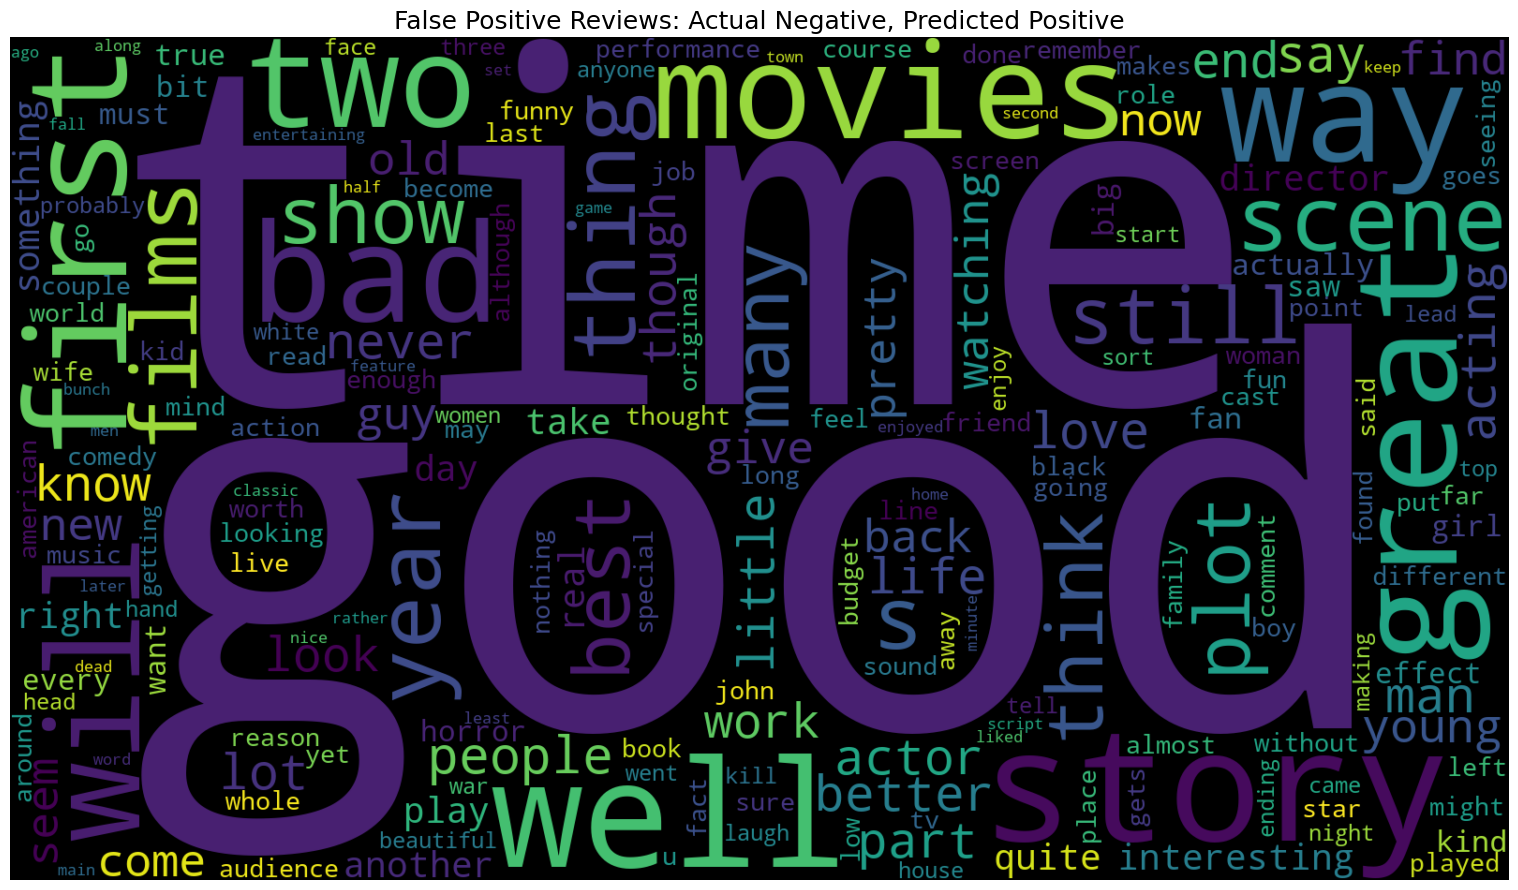

Saved: qwen3_imdb_lora\results\wordclouds\wordcloud_false_positive.png


In [6]:
false_positive_path = (
    OUTPUT_DIR / "wordcloud_false_positive.png"
)

if false_positive_text.strip():
    false_positive_cloud = create_wordcloud(
        false_positive_text,
        "False Positive Reviews: Actual Negative, Predicted Positive",
        false_positive_path,
    )
else:
    print(
        "No False Positive review text was found. "
        "The word cloud was skipped."
    )

## 6. Create the False Negative word cloud

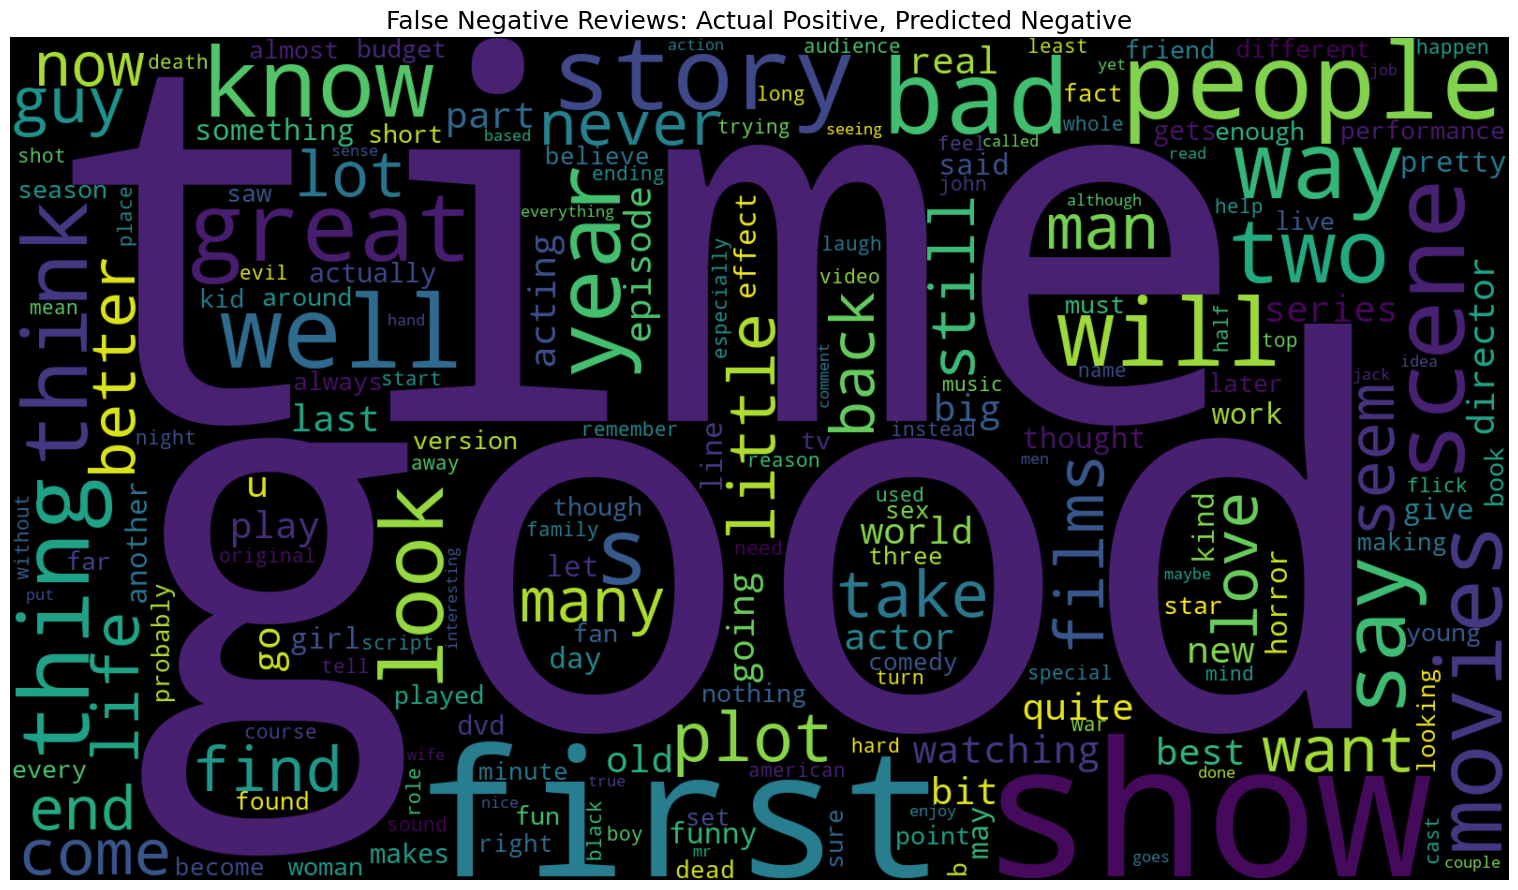

Saved: qwen3_imdb_lora\results\wordclouds\wordcloud_false_negative.png


In [7]:
false_negative_path = (
    OUTPUT_DIR / "wordcloud_false_negative.png"
)

if false_negative_text.strip():
    false_negative_cloud = create_wordcloud(
        false_negative_text,
        "False Negative Reviews: Actual Positive, Predicted Negative",
        false_negative_path,
    )
else:
    print(
        "No False Negative review text was found. "
        "The word cloud was skipped."
    )

## 7. Display the most frequent words

This section is optional. It lists the highest-frequency words used in each word cloud.

In [8]:
def get_top_words(
    cloud: WordCloud,
    number_of_words: int = 30,
) -> pd.DataFrame:
    words = sorted(
        cloud.words_.items(),
        key=lambda item: item[1],
        reverse=True,
    )[:number_of_words]

    return pd.DataFrame(
        words,
        columns=["Word", "Relative frequency"],
    )


if "false_positive_cloud" in globals():
    print("Top words in False Positive reviews:")
    display(get_top_words(false_positive_cloud))

if "false_negative_cloud" in globals():
    print("Top words in False Negative reviews:")
    display(get_top_words(false_negative_cloud))

Top words in False Positive reviews:


,Word,Relative frequency
0,good,1.000000
1,time,0.812500
2,story,0.658333
3,well,0.591667
4,great,0.529167
5,first,0.508333
6,way,0.504167
7,bad,0.495833
8,movies,0.479167
9,two,0.454167


Top words in False Negative reviews:


,Word,Relative frequency
0,good,1.000000
1,time,0.902985
2,show,0.809701
3,first,0.712687
4,people,0.690299
5,bad,0.652985
6,story,0.645522
7,scene,0.645522
8,well,0.638060
9,know,0.574627
